# Decision Tree Classifier — Step by Step

This notebook builds a Decision Tree classifier from scratch using **scikit-learn**, on the classic **Iris flower dataset**.

**Steps covered:**
1. Load and explore the dataset
2. Split into train/test sets
3. Train a Decision Tree
4. Visualize the tree
5. Evaluate accuracy
6. Look at feature importance
7. Compare different `max_depth` and `criterion` settings
8. Make a prediction on a new sample


## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

%matplotlib inline


## Step 2: Load the Dataset

We use the **Iris dataset** — 150 samples of iris flowers, 4 features, 3 species (classes).

In [2]:
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="species")

df = X.copy()
df["species"] = y.map(dict(enumerate(iris.target_names)))

print("Shape:", X.shape)
df.head()


Shape: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Step 3: Explore the Data

In [3]:
print(df["species"].value_counts())
df.describe()


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Step 4: Train/Test Split

We hold out 30% of the data for testing so we can check how well the tree generalizes.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])


Train size: 105
Test size : 45


## Step 5: Train the Decision Tree

We use `criterion="entropy"` so the split rule matches the Information Gain math (same idea as the manual examples earlier).

In [6]:
clf = DecisionTreeClassifier(
    criterion="entropy",   # use Information Gain (same as our manual calculations)
    max_depth=3,           # limit depth so the tree stays readable
    random_state=42
)

clf.fit(X_train, y_train)


DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

## Step 6: Visualize the Tree

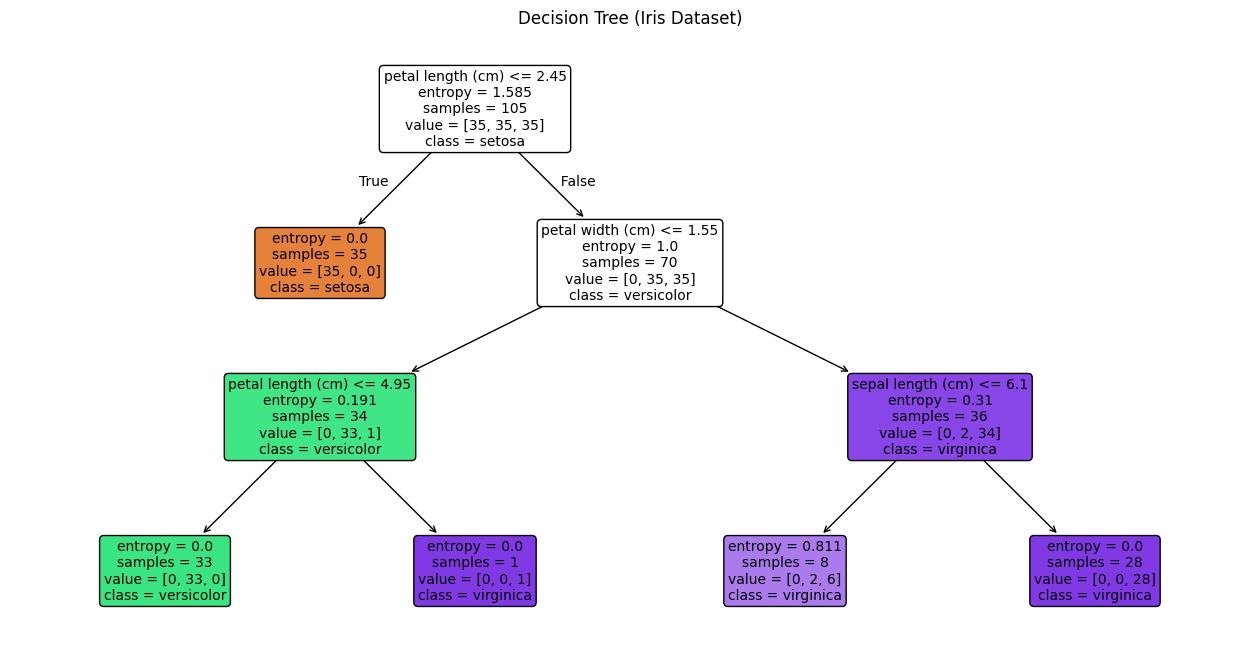

In [7]:
plt.figure(figsize=(16, 8))
plot_tree(
    clf,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree (Iris Dataset)")
plt.show()


You can also print the tree as plain text rules:

In [ ]:
print(export_text(clf, feature_names=list(iris.feature_names)))


## Step 7: Evaluate on Test Data

In [8]:
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=iris.target_names))


Accuracy: 0.933

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.80      0.89        15
   virginica       0.83      1.00      0.91        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45



## Step 8: Feature Importance

Which feature did the tree rely on most? (This lines up with the Information Gain idea — the feature picked at the root usually has the highest importance.)

In [ ]:
importances = pd.Series(clf.feature_importances_, index=iris.feature_names)
importances = importances.sort_values(ascending=False)

importances.plot(kind="barh", color="teal")
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

importances


## Step 9: Compare Different Depths and Criteria

Try a few settings side by side to see how `max_depth` and `criterion` affect accuracy.

In [10]:
results = []

for criterion in ["entropy", "gini"]:
    for depth in [1, 2, 3, 4, None]:
        model = DecisionTreeClassifier(criterion=criterion, max_depth=depth, random_state=42)
        model.fit(X_train, y_train)
        acc = accuracy_score(y_test, model.predict(X_test))
        results.append({"criterion": criterion, "max_depth": depth, "accuracy": acc})

results_df = pd.DataFrame(results)
results_df


,criterion,max_depth,accuracy
0,entropy,1.0,0.666667
1,entropy,2.0,0.888889
2,entropy,3.0,0.933333
3,entropy,4.0,0.888889
4,entropy,NaN,0.888889
5,gini,1.0,0.666667
6,gini,2.0,0.888889
7,gini,3.0,0.977778
8,gini,4.0,0.888889
9,gini,NaN,0.933333


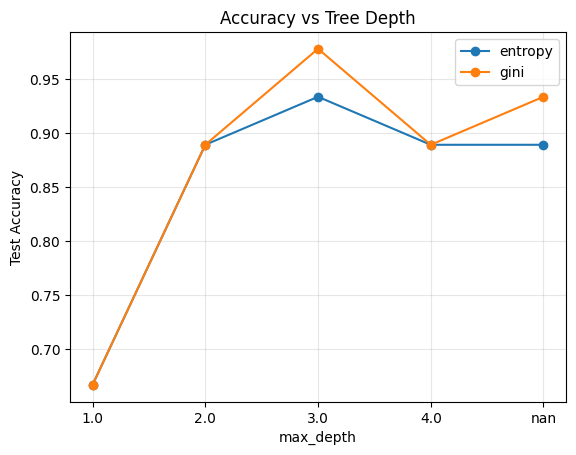

In [11]:
for criterion in results_df["criterion"].unique():
    subset = results_df[results_df["criterion"] == criterion]
    plt.plot(subset["max_depth"].astype(str), subset["accuracy"], marker="o", label=criterion)

plt.xlabel("max_depth")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs Tree Depth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Step 10: Predict on a New Sample

Let's classify a brand-new flower measurement.

In [ ]:
new_sample = pd.DataFrame(
    [[5.0, 3.4, 1.5, 0.2]],   # sepal length, sepal width, petal length, petal width
    columns=iris.feature_names
)

prediction = clf.predict(new_sample)[0]
probabilities = clf.predict_proba(new_sample)[0]

print("Predicted species:", iris.target_names[prediction])
print()
for name, prob in zip(iris.target_names, probabilities):
    print(f"  {name}: {prob:.2f}")


## Summary

- We trained a `DecisionTreeClassifier` using **entropy / information gain** — the same math from the manual Outlook/Wind examples, just automated by scikit-learn.
- The tree picks the most informative feature to split on first (root), exactly like choosing **Wind** over **Outlook** because it had higher IG.
- `max_depth` controls overfitting — deeper trees fit training data better but can generalize worse.
- Feature importance shows which attribute the tree relied on most, confirming which feature had the highest gain overall.

### Try next
- Swap `load_iris()` for `load_wine()` or `load_breast_cancer()` (also built into scikit-learn) to practice on a different dataset.
- Change `criterion="gini"` and compare the resulting tree shape to the entropy version.
